In [26]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from bmc.simulate import simulate_zspec
from bmc.utils.eval import plot_z, calc_mtr_asym

In [27]:
wdir        = Path().resolve().parent
seq_file    = wdir / "seq_lib" / "zspec_block.seq"
config_file = wdir / "sim_lib" / "config_1pool.yaml"

### Simulate

In [28]:
offsets, m_z = simulate_zspec(
    config_file=config_file,
    seq_file=seq_file,
    show_plot=False,
    norm_threshold=295,
)

print(f"Offsets: {offsets.shape}  ({offsets[0]:.1f} ... {offsets[-1]:.1f} ppm)")
print(f"Mz:      {m_z.shape}")

Z-spectrum: 100%|██████████| 402/402 [00:00<00:00, 3276.58it/s]

Offsets: (200,)  (-10.0 ... 10.0 ppm)
Mz:      (200,)


### Z-Spectrum

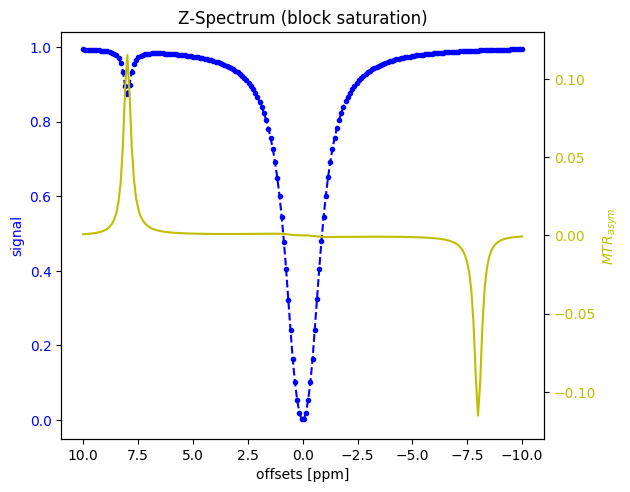

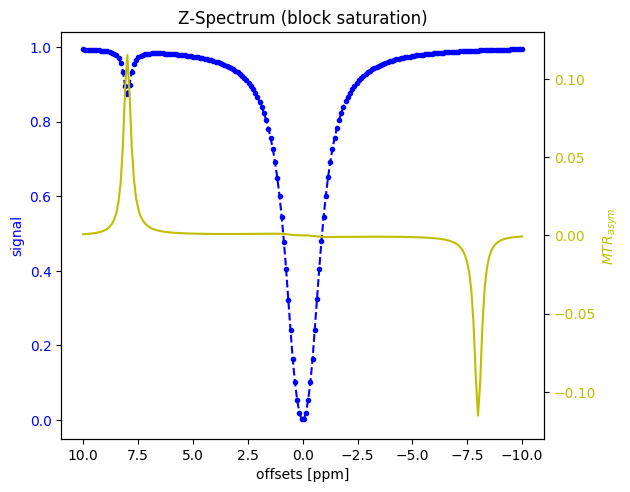

In [29]:
plot_z(
    m_z=m_z,
    offsets=offsets,
    title="Z-Spectrum (block saturation)",
    plot_mtr_asym=True,
)

### MTRasym

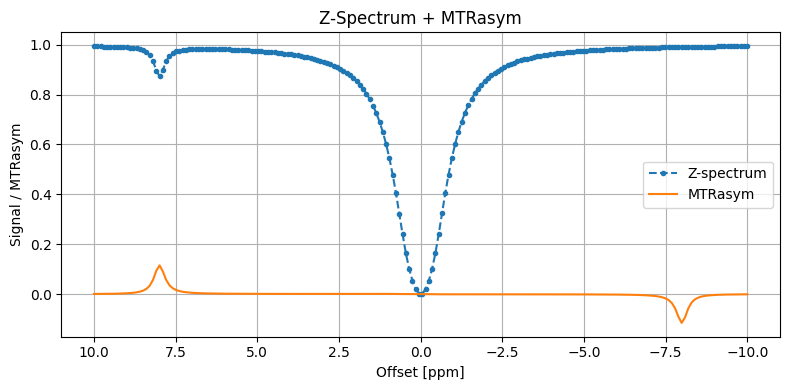

In [30]:
mtr = calc_mtr_asym(m_z=m_z, offsets=offsets)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(offsets, m_z, '.--', label='Z-spectrum')
ax.plot(offsets, mtr, label='MTRasym')
ax.invert_xaxis()
ax.set_xlabel('Offset [ppm]')
ax.set_ylabel('Signal / MTRasym')
ax.set_title('Z-Spectrum + MTRasym')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()